# Telco Customer Churn Prediction

## Business Objective

The telecom company wants to identify customers who are likely to churn so that the retention team can proactively engage with them.

**Target variable:** `Churn` (`Yes` / `No`)

This notebook follows the assignment workflow:

**Business Problem → Data Understanding → Preparation → EDA → Feature Engineering → Model Development → Evaluation → Interpretation → Model Saving → API**

The final solution uses a leakage-safe scikit-learn pipeline and a Decision Tree classifier.

In [1]:
# 1. Import libraries
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path("..")
DATA_PATH = ROOT / "data" / "TelcoCustomerChurn.csv"
DICTIONARY_PATH = ROOT / "data" / "TelcoCustomerChurn - Data Dictionary.csv"
MODEL_PATH = ROOT / "model" / "churn_pipeline.pkl"

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the dataset and data dictionary

In [2]:
df = pd.read_csv(DATA_PATH)
data_dictionary = pd.read_csv(DICTIONARY_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nData dictionary:")
display(data_dictionary)

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data dictionary:


,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"


## 3. Data Understanding

The supplied dataset has 7,043 customer records and 21 columns.

`customerID` is a unique identifier and is excluded from machine learning because it does not represent a customer behaviour pattern. The CSV's row index is also not a business feature.

`TotalCharges` is stored as text in the supplied file, so it must be converted to numeric before modelling.

In [3]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary:")
display(df.describe(include="all").T)

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Shape: (7043, 21)

Data types:


,Data Type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Duplicate rows: 0
Duplicate customer IDs: 0


## 4. Missing-value analysis

First inspect missing values in their original form. `TotalCharges` contains blank values in this dataset; these are converted to numeric and become missing values (`NaN`).

In [4]:
print("Missing values before numeric conversion:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing"))

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing"))

Missing values before numeric conversion:


,Missing
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Missing values after converting TotalCharges:


,Missing
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


### Preprocessing decisions

- Convert `TotalCharges` from text to numeric.
- Missing numeric values are handled by median imputation inside the model pipeline.
- Missing categorical values, if any, are handled by most-frequent imputation inside the model pipeline.
- Categorical columns are one-hot encoded.
- `customerID` is removed because it is an identifier.
- The target `Churn` is removed from the feature set before training.
- Preprocessing is fitted only on training data through the pipeline, preventing leakage.

## 5. Numerical and categorical features

In [5]:
TARGET = "Churn"
ID_COLUMNS = ["customerID"]

numeric_features_original = df.drop(columns=[TARGET] + ID_COLUMNS).select_dtypes(include=np.number).columns.tolist()
categorical_features_original = df.drop(columns=[TARGET] + ID_COLUMNS).select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numeric_features_original)

print("\nCategorical features:")
print(categorical_features_original)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6. Target analysis

The target is converted to binary values for the classifier:

- `No` → 0
- `Yes` → 1

A churn model is a classification problem because the output is one of two classes.

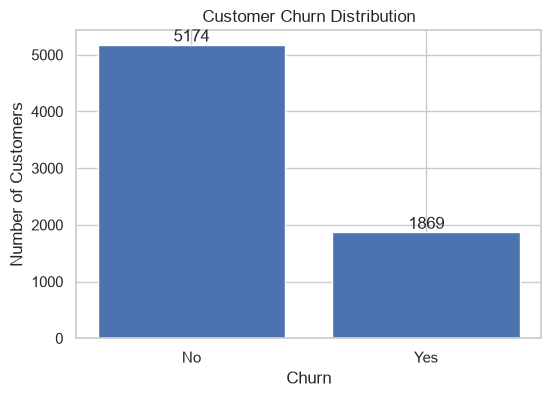

Churn percentage:


Churn
No     73.46
Yes    26.54
Name: Percentage, dtype: float64

In [6]:
target_counts = df[TARGET].value_counts().reindex(["No", "Yes"])
plt.figure(figsize=(6, 4))
bars = plt.bar(target_counts.index, target_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
for bar, value in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, str(value), ha="center", va="bottom")
plt.show()

print("Churn percentage:")
display((target_counts / len(df) * 100).round(2).rename("Percentage"))

**Business insight:** The classes are imbalanced: customers who do not churn are more numerous than customers who churn. This is important because a model that predicts only the majority class could have high accuracy while missing many churners. Therefore recall is important for the retention use case.

# 7. Exploratory Data Analysis

The following visualizations examine customer characteristics and their relationship with churn.

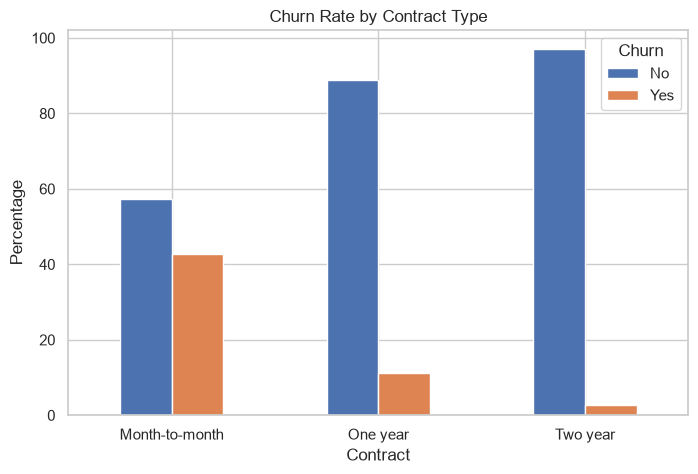

In [7]:
# Visualization 2: Churn by contract
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn[["No", "Yes"]].plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

**Business insight:** Month-to-month customers show a substantially higher churn rate than customers on longer contracts. Contract type is therefore a strong retention signal.

<Figure size 800x500 with 0 Axes>

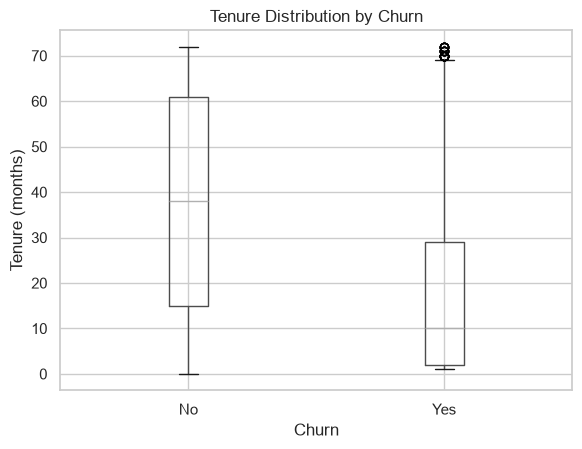

In [8]:
plt.figure(figsize=(8, 5))
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

**Business insight:** Churned customers tend to have shorter tenure. Early-stage customers are therefore an important group for proactive retention.

<Figure size 800x500 with 0 Axes>

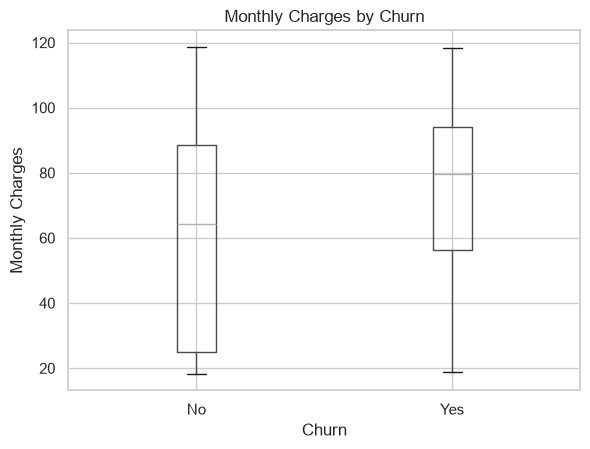

In [9]:
plt.figure(figsize=(8, 5))
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

**Business insight:** Customers who churn generally have higher monthly charges than customers who stay. Pricing and perceived value should therefore be considered in retention strategies.

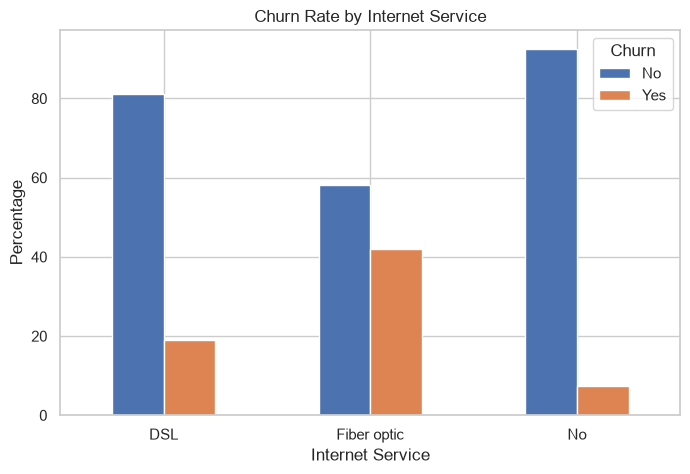

In [10]:
# Visualization 5: Churn by internet service
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn[["No", "Yes"]].plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

**Business insight:** Internet service type is associated with different churn rates. This indicates that service technology and customer experience can be useful retention signals.

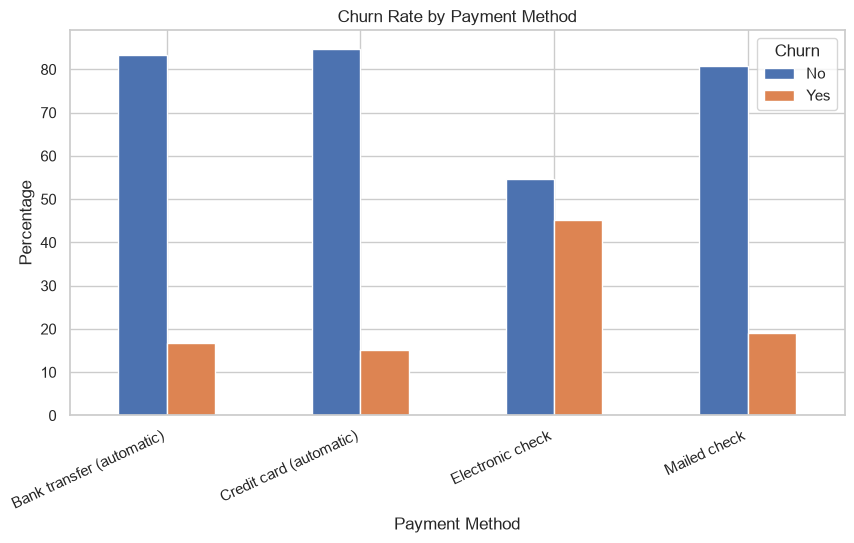

In [11]:
# Visualization 6: Churn by payment method
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn[["No", "Yes"]].plot(kind="bar", figsize=(10, 5))
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Churn")
plt.show()

**Business insight:** Churn behaviour varies by payment method. Payment method can therefore help the retention team identify groups that may need targeted engagement.

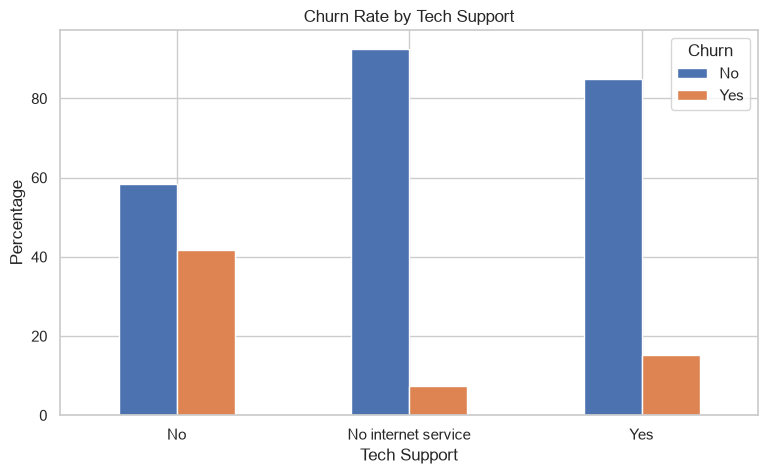

In [12]:
# Visualization 7: Churn by technical support
tech_churn = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100
tech_churn[["No", "Yes"]].plot(kind="bar", figsize=(9, 5))
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

**Business insight:** Technical support status is related to churn behaviour. Customers without support may represent an opportunity for service-quality or support-focused retention offers.

## 8. Feature Engineering

Two meaningful features are created:

1. **AverageMonthlySpend** = `TotalCharges / tenure`
   - Normalizes historical spend by customer tenure.
   - Useful for comparing customers with different lengths of service.

2. **ServiceCount**
   - Counts how many of the phone/internet add-on services are marked `Yes`.
   - Represents how broadly the customer uses the company's services.

These transformations are row-level and do not use the target variable.

In [13]:
import sys
sys.path.append(str(ROOT))

from model_utils import FeatureEngineer

feature_demo = FeatureEngineer().fit_transform(df.drop(columns=["Churn", "customerID"]))
display(feature_demo[["tenure", "TotalCharges", "AverageMonthlySpend", "ServiceCount"]].head())

,tenure,TotalCharges,AverageMonthlySpend,ServiceCount
0,1,29.85,29.850000,1
1,34,1889.50,55.573529,3
2,2,108.15,54.075000,3
3,45,1840.75,40.905556,3
4,2,151.65,75.825000,1


## 9. Train/Test Split

The assignment requires a 70:30 split with `random_state=42`.

`stratify=y` is also used to preserve the churn class ratio in both sets.

In [14]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training churn rate:", round(y_train.mean(), 4))
print("Testing churn rate:", round(y_test.mean(), 4))

Training rows: 4930
Testing rows: 2113
Training churn rate: 0.2653
Testing churn rate: 0.2655


## 10. Leakage-safe preprocessing pipeline

The preprocessing is placed inside an sklearn `Pipeline`:

`Raw data → Feature Engineering → Imputation/Encoding → Decision Tree`

This means the same transformations are automatically reused when the API receives an unseen customer.

In [15]:
NUMERIC_FEATURES = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges",
    "AverageMonthlySpend", "ServiceCount"
]

CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CATEGORICAL_FEATURES
        )
    ]
)

def build_pipeline(model):
    return Pipeline([
        ("features", FeatureEngineer()),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

# 11. Model Development

The mandatory algorithm is a Decision Tree. Two configurations are compared.

### Model 1 — Baseline
- `max_depth=5`
- `min_samples_split=10`

### Model 2 — Recall Focused
- `max_depth=6`
- `min_samples_split=10`
- `min_samples_leaf=3`
- `class_weight="balanced"`

The second model gives additional weight to the minority churn class, which is useful when missing a churner is more costly than contacting a non-churner.

In [16]:
model_1 = build_pipeline(
    DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        random_state=42
    )
)

model_2 = build_pipeline(
    DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=10,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42
    )
)

model_1.fit(X_train, y_train)
model_2.fit(X_train, y_train)

pred_1 = model_1.predict(X_test)
pred_2 = model_2.predict(X_test)

## 12. Model Evaluation

In [17]:
def metric_row(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

comparison = pd.DataFrame([
    metric_row("Decision Tree - Baseline", y_test, pred_1),
    metric_row("Decision Tree - Recall Focused", y_test, pred_2)
])

display(comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}"
}))

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree - Baseline,0.7937,0.6138,0.6007,0.6072
1,Decision Tree - Recall Focused,0.7459,0.5145,0.7576,0.6128


In [18]:
final_predictions = pred_2

### Confusion Matrix — Final Model

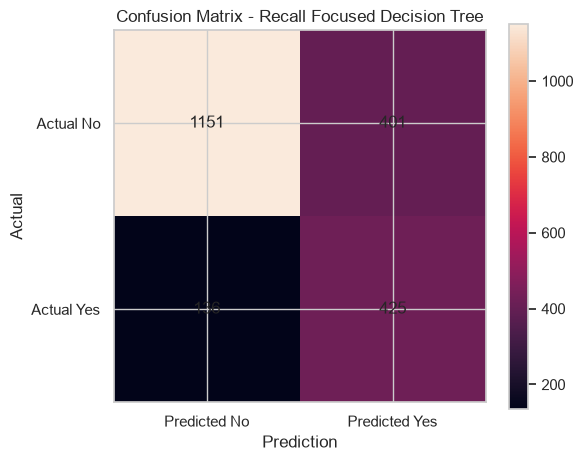

Classification report:
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1552
       Churn       0.51      0.76      0.61       561

    accuracy                           0.75      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.79      0.75      0.76      2113



In [19]:
cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Recall Focused Decision Tree")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Predicted No", "Predicted Yes"])
plt.yticks([0, 1], ["Actual No", "Actual Yes"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

print("Classification report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

## 13. Precision vs Recall — Business Decision

For telecom churn prediction, **Recall should generally be prioritized**.

- **False Negative:** The model says the customer will stay, but the customer actually churns. The retention team misses a potentially lost customer.
- **False Positive:** The model says the customer may churn, but the customer stays. The company may spend money contacting a customer unnecessarily.

In a proactive retention campaign, missing a true churner can be more expensive than contacting some customers who would not have churned. Therefore the final model is selected with recall as the main business priority, while still monitoring precision and F1.

In [20]:
final_model = model_2.named_steps["model"]
feature_names = model_2.named_steps["preprocessor"].get_feature_names_out()

import pandas as pd
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

# 14. Feature Importance

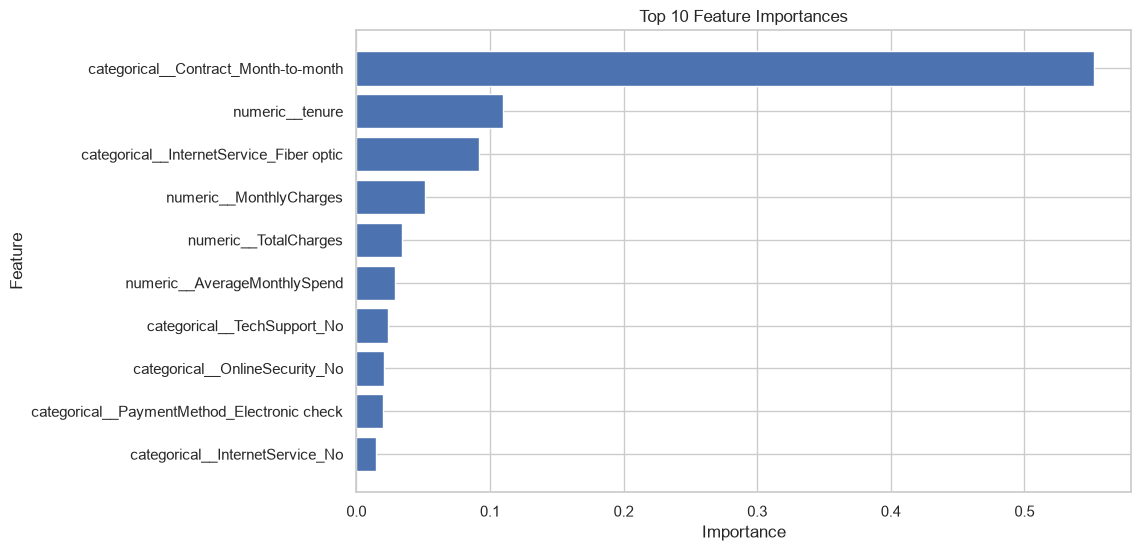

In [21]:
top10 = importance_df.head(10).sort_values("Importance")
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Interpretation:** In this trained tree, contract type, tenure, internet service and monthly charges are among the strongest signals. The exact importance values are model-specific and should be interpreted as predictive signals, not proof that a feature directly causes churn.

# 15. Decision Tree Visualization

The tree is visualized after preprocessing. Because one-hot encoding creates many columns, only the first levels are shown to keep the diagram readable.

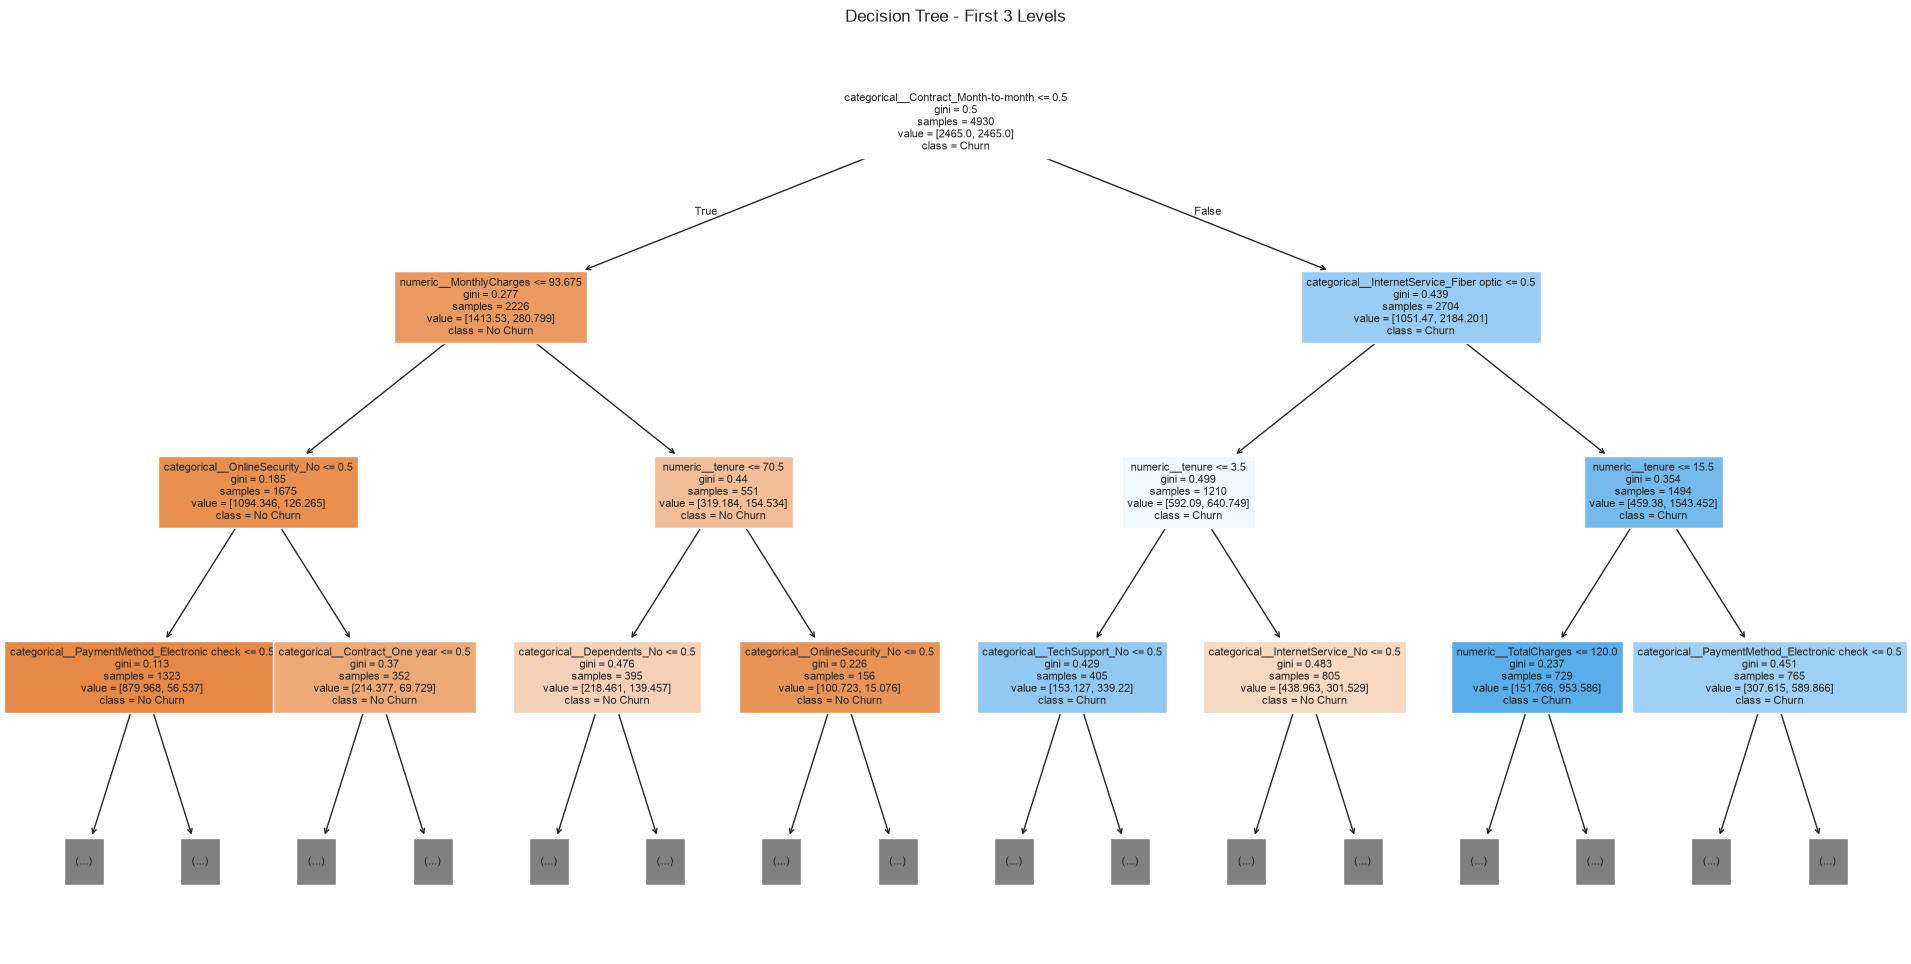

In [22]:
plt.figure(figsize=(24, 12))
plot_tree(
    final_model,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree - First 3 Levels")
plt.show()

# 16. Final Model Selection

The recall-focused model is selected because the business objective is proactive churn prevention.

The trade-off is visible in the evaluation results: increasing recall can reduce precision and overall accuracy. This is an intentional business trade-off.

The final model is saved together with all preprocessing steps so the API receives raw customer attributes and applies exactly the same transformations used during training.

In [23]:
# Fit the final pipeline on the training set and save it.
final_pipeline = model_2
final_pipeline.fit(X_train, y_train)

joblib.dump(final_pipeline, MODEL_PATH)

print(f"Final pipeline saved to: {MODEL_PATH}")

Final pipeline saved to: ..\model\churn_pipeline.pkl


# 17. Example Prediction

The saved pipeline can predict a new customer directly from the original input columns.

In [24]:
sample_customer = X_test.iloc[[0]].copy()

prediction = final_pipeline.predict(sample_customer)[0]
probability = final_pipeline.predict_proba(sample_customer)[0][1]

print("Prediction:", "Yes" if prediction == 1 else "No")
print("Churn probability:", round(float(probability), 4))

Prediction: Yes
Churn probability: 0.7618


# 18. Final Assignment Findings

### Data preparation
- The dataset contains 7,043 customer records.
- `TotalCharges` requires numeric conversion.
- `customerID` is excluded because it is an identifier.
- Preprocessing is handled inside a reusable sklearn pipeline.

### EDA
The charts show that churn behaviour varies by contract, tenure, monthly charges, internet service, payment method and support services.

### Feature engineering
- `AverageMonthlySpend`
- `ServiceCount`

### Model
Two Decision Tree configurations were evaluated. The recall-focused model uses `class_weight="balanced"` to give more attention to churners.

### Business recommendation
Prioritize **recall** for the first-stage retention screening. The retention team can then apply business rules or campaign capacity limits to decide which predicted churners should receive an offer.

### Deployment
The complete pipeline is saved as `model/churn_pipeline.pkl` and is consumed by the FastAPI `POST /predict` endpoint.